<a href="https://colab.research.google.com/github/crezny/DATASCI266_final_project/blob/main/Baseline Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Scoring Model

In [2]:
%pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.4 MB/s eta 0:00:00


In [1]:
import pandas as pd
import evaluate
import re
import numpy as np
import pandas as pd
from rouge_score import rouge_scorer, scoring
from sentence_transformers import SentenceTransformer
from typing import List, Dict, Optional, Tuple, Any, Sequence
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import math
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'evaluate'

### LLM SSM Evaluation

In [ ]:
"""Load  semantic similarity model"""
model_name='BAAI/bge-large-en-v1.5'
alternate_sentence_transformer = 'all-MiniLM-L6-v2'
print(f"Loading model: {model_name}...")
sentence_model = SentenceTransformer(model_name)
print("Model loaded successfully!\n")


# Load Rouge Scorer
rouge = evaluate.load('rouge')
bleu = evaluate.load("bleu")

bleurt_tokenizer = AutoTokenizer.from_pretrained("Elron/bleurt-base-512")
bleurt_model = AutoModelForSequenceClassification.from_pretrained("Elron/bleurt-base-512")


Loading model: BAAI/bge-large-en-v1.5...
Model loaded successfully!



In [ ]:
def create_scores(
        filepath: str,
):
    df = pd.read_csv(filepath)
    df['time_taken'] = pd.to_timedelta(df['time_taken'])

    df = df.assign(
        output=df["output"].fillna("").astype(str).str.strip().apply(lambda x: x.strip() if not isinstance(x, str) else re.sub(r"<think>.*?</think>", "", x, flags=re.DOTALL).strip()),
        golden=df["org_clause_text"].fillna("").astype(str).str.strip()
    )
    preds = df["output"].fillna("").astype(str).tolist()
    refs = df["golden"].fillna("").astype(str).tolist()

    E_out = embed(preds)
    E_gold = embed(refs)


    rouge_scores = rouge.compute(predictions=preds, references=refs, use_aggregator=False)
    bleu_results = bleu.compute(predictions=preds, references=refs)


    time_list = df['time_taken'].dt.total_seconds().tolist()
    # Normalize to unit vectors for cosine via dot product
    eps = 1e-12
    E_out  = E_out  / (np.linalg.norm(E_out,  axis=1, keepdims=True) + eps)
    E_gold = E_gold / (np.linalg.norm(E_gold, axis=1, keepdims=True) + eps)
    sts_scores = np.einsum('ij,ij->i', E_out, E_gold)
    return sts_scores, time_list, rouge_scores, bleu_results

model = SentenceTransformer("BAAI/bge-large-en-v1.5")

def embed(texts, batch_size=64):
    # Recommended BGE instruction-style prefix; use the SAME for both sides
    prefixed = [f"Represent this sentence for measuring semantic similarity: {t}" for t in texts]
    return model.encode(
        prefixed,
        batch_size=batch_size,
        normalize_embeddings=True,        # important: makes dot product == cosine
        convert_to_numpy=True,
        show_progress_bar=True
    )

In [ ]:
# df has columns: "output", "golden"
# Make sure NaNs are handled
SmolLM3_sts_scores, SmolLM3_time_list, SmolLM3_scores, SmolLM3_bleu_results = create_scores('data/baseline_results/baseline_SmolLM3_outputs.csv')
Llama_3_2_3B_Instruct_sts_scores, Llama_3_2_3B_Instruct_time_list, Llama_3_2_3B_Instruct_scores, Llama_3_2_3B_Instruct_bleu_results = create_scores('data/baseline_results/baseline_llama-3.2-3B-Instruct_outputs.csv')
Gemma_2_9B_sts_scores, Gemma_2_9B_time_list, Gemma_2_9B_scores, Gemma_2_9B_bleu_results = create_scores('data/baseline_results/baseline_Gemma-2-9B_outputs.csv')
Mistral_7B_Instruct_v0_3_sts_scores, Mistral_7B_Instruct_v0_3_time_list, Mistral_7B_Instruct_v0_3_scores, Mistral_7B_Instruct_v0_3_bleu_results = create_scores('data/baseline_results/baseline_Mistral-7B-Instruct-v0.3_outputs.csv')
Qwen3_8B_sts_scores, Qwen3_8B_time_list, Qwen3_8B_scores, Qwen3_8B_bleu_results = create_scores('data/baseline_results/baseline_Qwen3-8B_outputs.csv')


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
def _stack_offsets(
    x_vals: np.ndarray,
    *,
    base_y: float,
    step: float = 0.35,
    precision: int = 3,
) -> np.ndarray:
    """
    Deterministic "beeswarm-like" vertical offsets for repeated x values.
    - Quantizes x by rounding to `precision` decimals.
    - For each quantized bucket, assigns offsets symmetrically around base_y:
        0 -> 0
        1 -> +step
        2 -> -step
        3 -> +2*step
        4 -> -2*step
        ...
    Returns an array of y positions with same shape as x_vals.
    """
    x_vals = np.asarray(x_vals, dtype=float)
    q = np.round(x_vals, precision)
    y = np.empty_like(x_vals, dtype=float)

    # For reproducible ordering, we preserve the original order within each bucket
    # and assign offsets in a symmetric pattern.
    unique_buckets = np.unique(q)
    for b in unique_buckets:
        idx = np.where(q == b)[0]
        n = len(idx)
        if n == 1:
            y[idx[0]] = base_y
            continue

        # symmetric offsets: 0, +1, -1, +2, -2, ...
        ranks = np.arange(n)
        offsets = np.zeros(n, dtype=float)
        # build symmetric sequence
        seq = [0]
        k = 1
        while len(seq) < n:
            seq.append(+k)
            if len(seq) < n:
                seq.append(-k)
            k += 1
        offsets = np.array(seq, dtype=float) * step
        y[idx] = base_y + offsets

    return y


def plot_horizontal_violin_beeswarm_stacked(
    rouge_by_group: Dict[str, List[float]],
    *,
    ax: Optional[plt.Axes] = None,
    xlabel: str = "ROUGE-1",
    line_stat: str = "median",   # 'median' or 'mean'
    cap_height: float = 0.12,
    line_weight: float = 2.0,
    stack_step: float = 0.035,
    precision: int = 3,
    show_global_median: bool = True,
    max_possible: float = 1.0,
    min_possible: float = 0.0,
    title: str = "ROUGE-1 Scores by Model",
    label_suffix: str = "",
    base_color: str = "",   # distribution fill color (default blue)
    dot_color: str = "",
    hide_label: bool = False,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Multi-row horizontal violin + stacked dots + whisker line with end caps.
    Each group (key) gets its own row.

    Parameters are the same as before, plus:
      - ax: optional matplotlib Axes to draw into.
    Returns (fig, ax) without calling plt.show().
    """
    if not isinstance(rouge_by_group, dict) or not rouge_by_group:
        raise ValueError("rouge_by_group must be a non-empty dict of {label: list_of_scores}.")

    labels = list(rouge_by_group.keys())
    data = [np.asarray(rouge_by_group[k], dtype=float) for k in labels]
    positions = np.arange(1, len(labels) + 1, dtype=float)

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(9, max(2.0, 0.9 + 0.6 * len(labels))))
    else:
        fig = ax.figure


    ttl = title if not label_suffix else f"{title} — {label_suffix}"
    ax.set_title(ttl)

    # Shaded violins per row
    parts = ax.violinplot(
        data,
        positions=positions,
        vert=False,
        showmeans=False,
        showextrema=False,
        showmedians=False,
    )
    # Light fill for violins
    for pc in parts["bodies"]:
        if base_color != "":
            pc.set_facecolor(base_color)
            pc.set_edgecolor(base_color)
        pc.set_alpha(0.2)
        pc.set_linewidth(0.8)


    # Per-row overlays
    for pos, vals in zip(positions, data):
        if vals.size == 0:
            continue

        # stacked dots (deterministic)
        y = _stack_offsets(vals, base_y=pos, step=stack_step, precision=precision)

        if dot_color != "":
            ax.scatter(vals, y, s=14, alpha=0.85, color=dot_color)
        else:
            ax.scatter(vals, y, s=14, alpha=0.85)

        # whisker line min→max + end caps
        vmin, vmax = float(np.min(vals)), float(np.max(vals))
        ax.hlines(pos, vmin, vmax, linewidth=line_weight)
        # faint extension to max_possible (if vmax < max_possible)
        if vmin > min_possible:
            ax.hlines(
                    pos,
                    min_possible,
                    vmin,
                    linewidth=line_weight,
                    color="gray",
                    alpha=0.3,
                    linestyles="dashed",
                )
        if vmax < max_possible:
            ax.hlines(
                    pos,
                    vmax,
                    max_possible,
                    linewidth=line_weight,
                    color="gray",
                    alpha=0.3,
                    linestyles="dashed"
                )

        cap_y1, cap_y2 = pos - cap_height / 2.0, pos + cap_height / 2.0
        ax.vlines([vmin, vmax], cap_y1, cap_y2, linewidth=line_weight)

        # center stat marker (median or mean)
        stat_val = float(np.median(vals) if line_stat == "median" else np.mean(vals))
        ax.vlines(stat_val, cap_y1, cap_y2, linewidth=line_weight)

    # Optional global median line across all rows
    if show_global_median:
        all_vals = np.concatenate([v for v in data if v.size])
        if all_vals.size:
            stat_val = float(np.median(all_vals) if line_stat == "median" else np.mean(all_vals))
            ax.axvline(stat_val, color="darkgray", linestyle="-", linewidth=line_weight,
                       label=f"{line_stat.title()} = {stat_val:.3f}")

            # Text label near the top, like BLEU avg
            # ax.text(stat_val, len(labels) + 0.6, f"{line_stat.title()} = {stat_val:.3f}",
            #         color="gray", fontsize=9, ha="center", va="bottom")


            ax.legend(frameon=False, fontsize=9, loc="upper right")


    # Styling like a SHAP beeswarm
    ax.set_yticks(positions)

    ax.set_yticklabels(labels)
    for label_text, tick in zip(labels, ax.yaxis.get_major_ticks()):
        if not label_text:  # catches '' or None
            tick.tick1line.set_visible(False)  # left tick
            tick.tick2line.set_visible(False)  # right tick
            tick.label1.set_visible(False)     # hide text as well just in case
    # if xlabel != "":
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_ylim(0.5, len(labels) + 0.5)
    # remove all borders
    for spine in ax.spines.values():
        spine.set_visible(False)


    if created_fig:
        fig.tight_layout()
    return fig, ax


In [ ]:
def _fmt(x: float) -> str:
    if x >= 0.1:   return f"{x:.2f}"
    if x >= 0.01:  return f"{x:.3f}"
    return f"{x:.4f}"


def _apply_clean_axes(ax):
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def plot_single_model_bleu_precisions(
    bleu_results: Dict[str, Any],
    *,
    ax: Optional[plt.Axes] = None,
    ylim: Tuple[float, float] = (0.0, 1.0),
    annotate: bool = True,
    rotation: int = 0,
    title: str = "BLEU n-gram Precisions (single model)",
    ylabel: str = "Precision (0–1)",
    label_suffix: Optional[str] = None,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot 1–4 gram precisions with colored bars and a BLEU average line.
    Expects: bleu_results["precisions"] (list of length 4) and bleu_results["bleu"] (float).
    """
    precisions: Sequence[float] = bleu_results.get("precisions", [float("nan")] * 4)
    p = (list(precisions) + [float("nan")] * 4)[:4]

    created_fig = ax is None
    if created_fig:
        fig, ax = plt.subplots(figsize=(6, 5))
    else:
        fig = ax.figure

    # harmonious palette (you can swap or override if desired)
    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

    x = np.arange(1, 5)
    bars = ax.bar(x, p, color=colors[: len(p)], edgecolor="black", linewidth=0.5)

    # add BLEU average line if available
    bleu_score = bleu_results.get("bleu")
    if bleu_score is not None and not math.isnan(bleu_score):
        ax.axhline(bleu_score, color="darkgray", linestyle="-", linewidth=1,
                   label=f"BLEU avg = {_fmt(bleu_score)}")
        ax.legend(frameon=False, fontsize=9, loc="upper right")

    # annotate bars
    if annotate:
        for rect, val in zip(bars, p):
            if not math.isnan(val):
                ax.text(rect.get_x() + rect.get_width()/2.0, rect.get_height(),
                        _fmt(val), ha="center", va="bottom", fontsize=9)

    # labels & formatting
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ttl = title if not label_suffix else f"{title} — {label_suffix}"
    ax.set_title(ttl)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}-gram" for i in x], rotation=rotation, ha="center")

    _apply_clean_axes(ax)

    # remove all borders
    for spine in ax.spines.values():
        spine.set_visible(False)


    # footer info
    bp = bleu_results.get("brevity_penalty", None)
    lr = bleu_results.get("length_ratio", None)
    footer_bits = []
    if bp is not None: footer_bits.append(f"BP={_fmt(float(bp))}")
    if lr is not None: footer_bits.append(f"LenRatio={_fmt(float(lr))}")
    if footer_bits:
        ax.text(0.98, -0.12, "  •  ".join(footer_bits), transform=ax.transAxes,
                ha="right", va="top", fontsize=9)

    if created_fig:
        fig.tight_layout()
    return fig, ax


In [ ]:
def set_plot_font_styles(
    fig,
    axis_size: int = 10,
    title_size: int = 12,
    annotation_size: int = 9,
    title_pad: int = 10,
) -> None:
    """
    Apply consistent font sizes and title spacing to all Axes in a matplotlib Figure.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure containing one or more Axes.
    axis_size : int
        Font size for axis labels and tick labels.
    title_size : int
        Font size for subplot titles.
    annotation_size : int
        Font size for legends and annotation text.
    title_pad : int
        Padding (points) between title and plot area.
    """
    for ax in fig.get_axes():
        # --- Title ---
        ax.title.set_fontsize(title_size)
        # Set consistent title padding (distance above axes)
        title_text = ax.get_title()
        if title_text:
            ax.set_title(title_text, fontsize=title_size, pad=title_pad)

        # --- Axis labels ---
        ax.xaxis.label.set_fontsize(axis_size)
        ax.yaxis.label.set_fontsize(axis_size)

        # --- Tick labels ---
        for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
            tick_label.set_fontsize(axis_size)

        # --- Legend text ---
        leg = ax.get_legend()
        if leg is not None:
            leg.get_title().set_fontsize(annotation_size)
            for text in leg.get_texts():
                text.set_fontsize(annotation_size)

        # --- Annotation text (e.g., BLEU avg or Median labels) ---
        for child in ax.get_children():
            if isinstance(child, plt.Text):
                txt = child.get_text()
                # Skip axis labels & titles
                if txt not in {ax.get_title(), ax.get_xlabel(), ax.get_ylabel()}:
                    child.set_fontsize(annotation_size)

    # Redraw to apply all sizing and layout
    fig.canvas.draw_idle()


## Rogues/BLEU scores for All Models

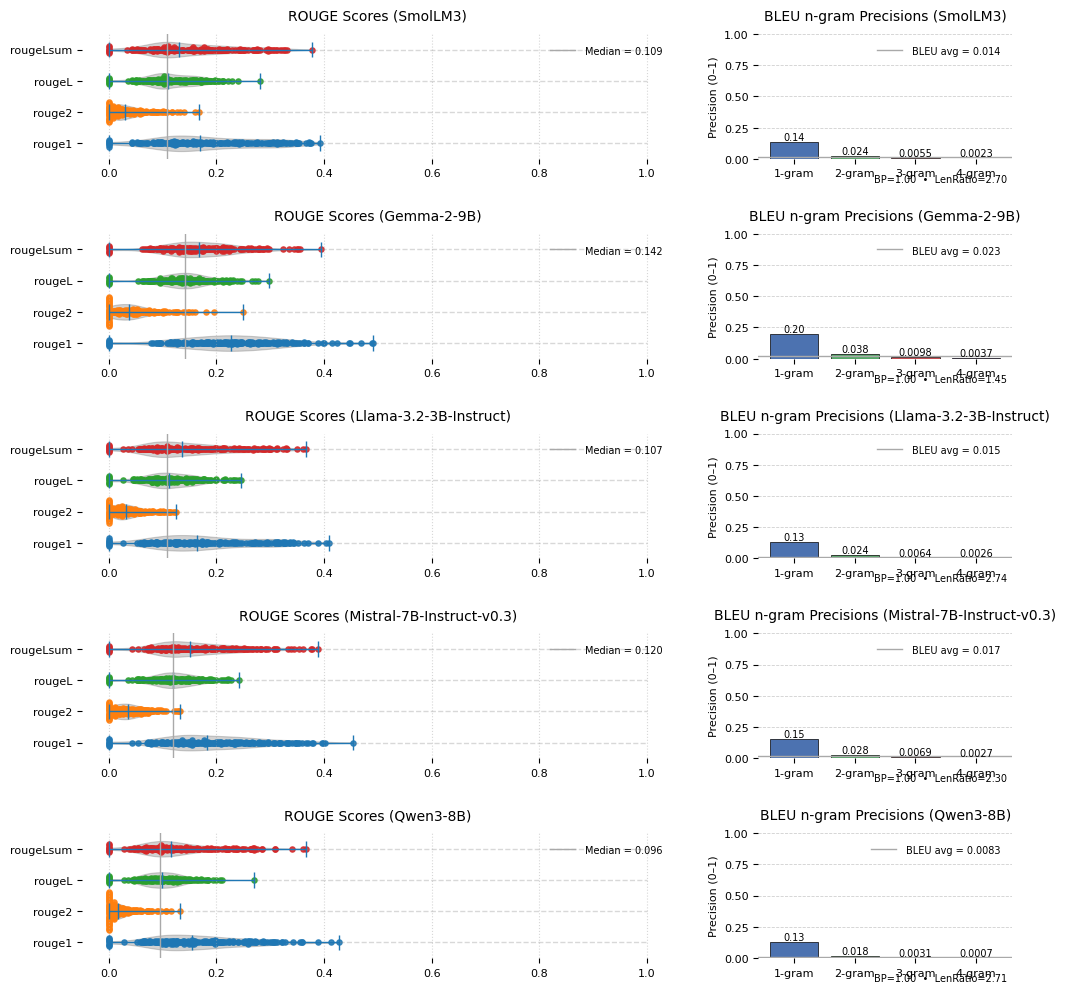

In [ ]:
fig, axes = plt.subplots(
    5, 2,
    figsize=(12, 12),
    gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)
axes = axes.flatten()

plot_single_model_bleu_precisions(SmolLM3_bleu_results, ax=axes[1], label_suffix="", title= "BLEU n-gram Precisions (SmolLM3)")
plot_single_model_bleu_precisions(Gemma_2_9B_bleu_results, ax=axes[3], label_suffix="", title= "BLEU n-gram Precisions (Gemma-2-9B)")
plot_single_model_bleu_precisions(Llama_3_2_3B_Instruct_bleu_results, ax=axes[5], label_suffix="", title= "BLEU n-gram Precisions (Llama-3.2-3B-Instruct)")
plot_single_model_bleu_precisions(Mistral_7B_Instruct_v0_3_bleu_results, ax=axes[7], label_suffix="", title= "BLEU n-gram Precisions (Mistral-7B-Instruct-v0.3)")
plot_single_model_bleu_precisions(Qwen3_8B_bleu_results, ax=axes[9], label_suffix="", title= "BLEU n-gram Precisions (Qwen3-8B)")

plot_horizontal_violin_beeswarm_stacked(SmolLM3_scores, ax=axes[0], xlabel="", title= "ROUGE Scores (SmolLM3)",cap_height=0.5, line_weight=1, base_color="#222222")
plot_horizontal_violin_beeswarm_stacked(Gemma_2_9B_scores, ax=axes[2], xlabel="", title= "ROUGE Scores (Gemma-2-9B)",cap_height=0.5, line_weight=1, base_color="#222222")
plot_horizontal_violin_beeswarm_stacked(Llama_3_2_3B_Instruct_scores, ax=axes[4], xlabel="", title= "ROUGE Scores (Llama-3.2-3B-Instruct)",cap_height=0.5, line_weight=1, base_color="#222222")
plot_horizontal_violin_beeswarm_stacked(Mistral_7B_Instruct_v0_3_scores, ax=axes[6], xlabel="", title= "ROUGE Scores (Mistral-7B-Instruct-v0.3)",cap_height=0.5, line_weight=1, base_color="#222222")
plot_horizontal_violin_beeswarm_stacked(Qwen3_8B_scores, ax=axes[8], xlabel="", title= "ROUGE Scores (Qwen3-8B)",cap_height=0.5, line_weight=1, base_color="#222222")




fig.subplots_adjust(hspace=0.6)
set_plot_font_styles(fig, axis_size=8, title_size=10, annotation_size=7)
plt.show()

## LLM-STS (BAAI/bge-large-en-v1.5) scores for All Models

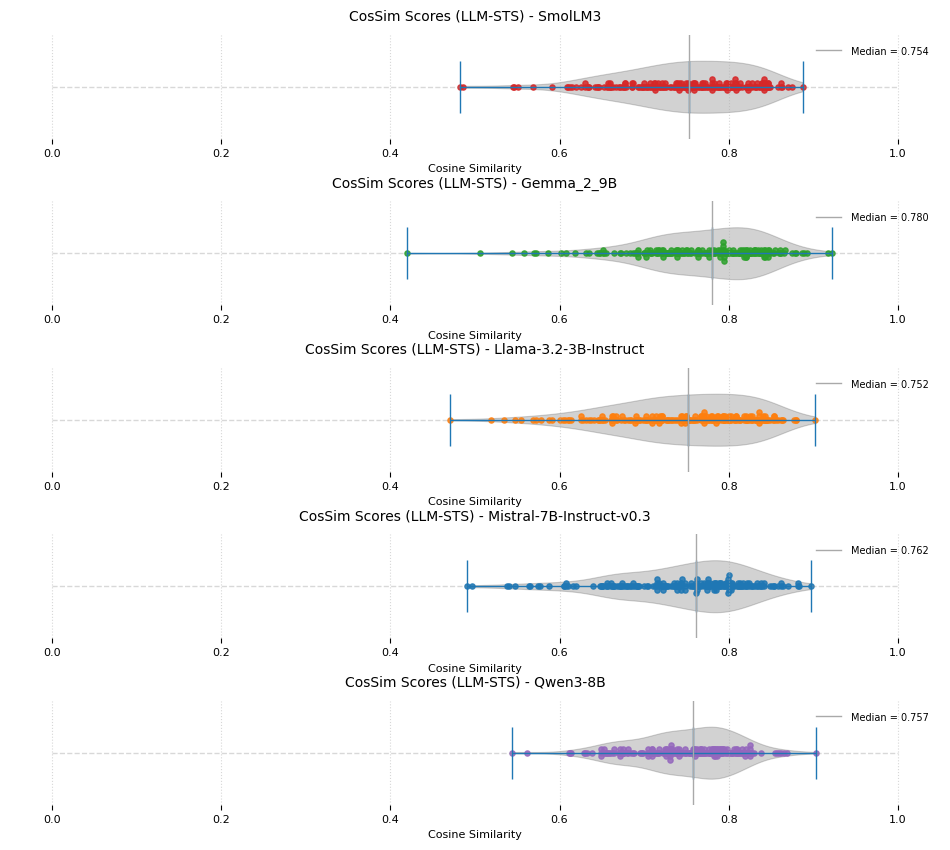

In [ ]:
fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 10),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)
axes = axes.flatten()
plot_horizontal_violin_beeswarm_stacked({None: SmolLM3_sts_scores}, ax=axes[0]
                                        , xlabel="Cosine Similarity"
                                        , line_stat="median"
                                        , title= "CosSim Scores (LLM-STS) - SmolLM3"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#d62728"
                                        # , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": Gemma_2_9B_sts_scores}, ax=axes[1]
                                        , xlabel="Cosine Similarity"
                                        , line_stat="median"
                                        , title= "CosSim Scores (LLM-STS) - Gemma_2_9B"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#2ca02c"
                                        , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({"": Llama_3_2_3B_Instruct_sts_scores}, ax=axes[2]
                                        , xlabel="Cosine Similarity"
                                        , line_stat="median"
                                        , title= "CosSim Scores (LLM-STS) - Llama-3.2-3B-Instruct"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#ff7f0e"
                                        , hide_label=True
                                        )
plot_horizontal_violin_beeswarm_stacked({"": Mistral_7B_Instruct_v0_3_sts_scores}, ax=axes[3]
                                        , xlabel="Cosine Similarity"
                                        , line_stat="median"
                                        , title= "CosSim Scores (LLM-STS) - Mistral-7B-Instruct-v0.3"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#1f77b4"
                                        , hide_label=True
                                        )
plot_horizontal_violin_beeswarm_stacked({"": Qwen3_8B_sts_scores}, ax=axes[4]
                                        , xlabel="Cosine Similarity"
                                        , line_stat="median"
                                        , title= "CosSim Scores (LLM-STS) - Qwen3-8B"
                                        , max_possible=1.0
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#9467bd"
                                        , hide_label=True
                                        )

# plot_horizontal_violin_beeswarm_stacked({"Llama-3.2-3B-Instruct": Llama_3_2_3B_Instruct_sts_scores}, ax=axes[1], xlabel="", title= "ROUGE Scores (Llama-3.2-3B-Instruct)",cap_height=0.5, line_weight=1)
# fig.tight_layout()
fig.subplots_adjust(hspace=0.6)
set_plot_font_styles(fig, axis_size=8, title_size=10, annotation_size=7)
plt.show()


## Execution Time Distriobution (local Quant 4K_M Files)

In [ ]:
math.ceil(max_time * 1.1)

231

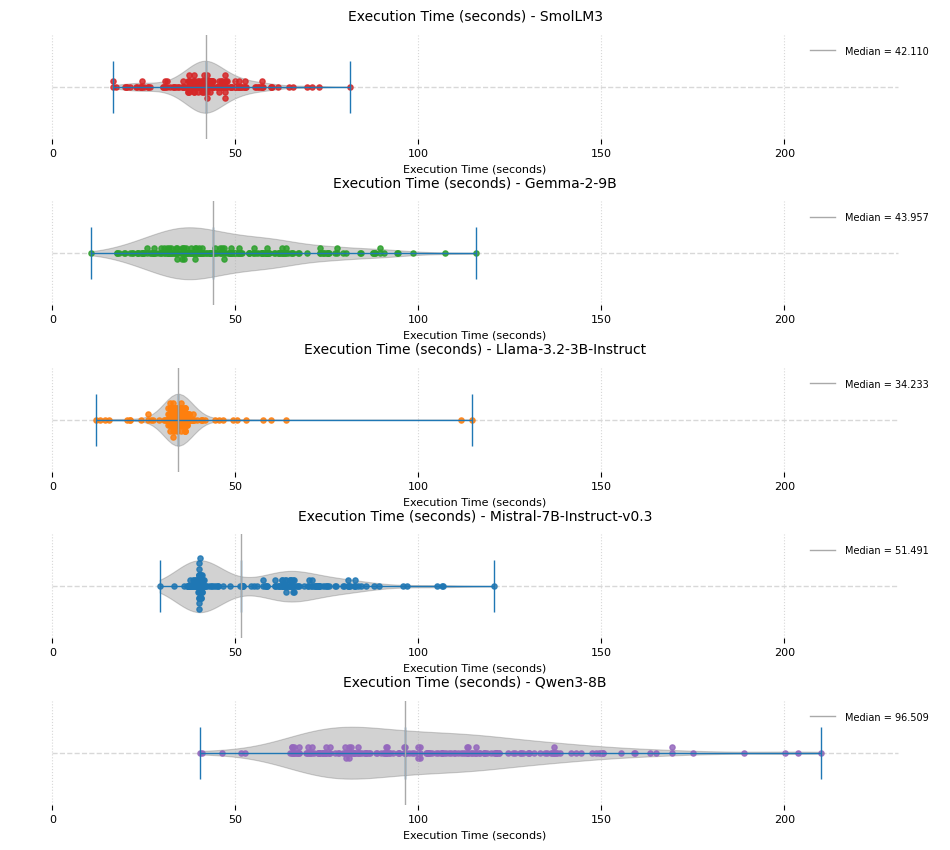

In [ ]:

fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 10),
    # gridspec_kw={"width_ratios": [7, 3]}   # 70/30 width split
)
axes = axes.flatten()
max_time = max(SmolLM3_time_list + Gemma_2_9B_time_list + Llama_3_2_3B_Instruct_time_list + Mistral_7B_Instruct_v0_3_time_list + Qwen3_8B_time_list)
max_time = math.ceil(max_time * 1.1)
plot_horizontal_violin_beeswarm_stacked({None: SmolLM3_time_list}, ax=axes[0]
                                        , xlabel="Execution Time (seconds)"
                                        , line_stat="median"
                                        , title= "Execution Time (seconds) - SmolLM3"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#d62728"
                                        , stack_step = 0.055
                                        , precision = 1,
                                        # , hide_label=True
                                        )

plot_horizontal_violin_beeswarm_stacked({None: Gemma_2_9B_time_list}, ax=axes[1]
                                        , xlabel="Execution Time (seconds)"
                                        , line_stat="median"
                                        , title= "Execution Time (seconds) - Gemma-2-9B"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#2ca02c"
                                        , stack_step = 0.055
                                        , precision = 1,
                                        # , hide_label=True
                                        )
plot_horizontal_violin_beeswarm_stacked({None: Llama_3_2_3B_Instruct_time_list}, ax=axes[2]
                                        , xlabel="Execution Time (seconds)"
                                        , line_stat="median"
                                        , title= "Execution Time (seconds) - Llama-3.2-3B-Instruct"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#ff7f0e"
                                        , stack_step = 0.055
                                        , precision = 1,
                                        # , hide_label=True
                                        )
plot_horizontal_violin_beeswarm_stacked({None: Mistral_7B_Instruct_v0_3_time_list}, ax=axes[3]
                                        , xlabel="Execution Time (seconds)"
                                        , line_stat="median"
                                        , title= "Execution Time (seconds) - Mistral-7B-Instruct-v0.3"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#1f77b4"
                                        , stack_step = 0.055
                                        , precision = 1,
                                        # , hide_label=True
                                        )
plot_horizontal_violin_beeswarm_stacked({None: Qwen3_8B_time_list}, ax=axes[4]
                                        , xlabel="Execution Time (seconds)"
                                        , line_stat="median"
                                        , title= "Execution Time (seconds) - Qwen3-8B"
                                        , max_possible=max_time
                                        , cap_height=0.5
                                        , line_weight=1
                                        , base_color="#222222"
                                        , dot_color="#9467bd"
                                        , stack_step = 0.055
                                        , precision = 1,
                                        # , hide_label=True
                                        )

fig.subplots_adjust(hspace=0.6)
set_plot_font_styles(fig, axis_size=8, title_size=10, annotation_size=7)
plt.show()
